In [208]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [209]:
df = pd.read_csv("kidney_disease.csv")
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [210]:
df.shape

(400, 26)

In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [212]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [213]:
df.drop("id", axis =  1 , inplace = True)

In [214]:
df.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [215]:
df.columns = [
    'Age',
    'Blood_Pressure',
    'Specific_Gravity',
    'Albumin',
    'Sugar',
    'Red_Blood_Cells',
    'Pus_Cell',
    'Pus_Cell_Clumps',
    'Bacteria',
    'Blood_Glucose_Random',
    'Blood_Urea',
    'Serum_Creatinine',
    'Sodium',
    'Potassium',
    'Hemoglobin',
    'Packed_Cell_Volume',
    'White_Blood_Cell_Count',
    'Red_Blood_Cell_Count',
    'Hypertension',
    'Diabetes_Mellitus',
    'Coronary_Artery_Disease',
    'Appetite',
    'Pedal_Edema',
    'Anemia',
    'Class'
]

In [216]:
df.columns

Index(['Age', 'Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar',
       'Red_Blood_Cells', 'Pus_Cell', 'Pus_Cell_Clumps', 'Bacteria',
       'Blood_Glucose_Random', 'Blood_Urea', 'Serum_Creatinine', 'Sodium',
       'Potassium', 'Hemoglobin', 'Packed_Cell_Volume',
       'White_Blood_Cell_Count', 'Red_Blood_Cell_Count', 'Hypertension',
       'Diabetes_Mellitus', 'Coronary_Artery_Disease', 'Appetite',
       'Pedal_Edema', 'Anemia', 'Class'],
      dtype='object')

In [217]:
df

,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Red_Blood_Cells,Pus_Cell,Pus_Cell_Clumps,Bacteria,Blood_Glucose_Random,...,Packed_Cell_Volume,White_Blood_Cell_Count,Red_Blood_Cell_Count,Hypertension,Diabetes_Mellitus,Coronary_Artery_Disease,Appetite,Pedal_Edema,Anemia,Class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [218]:
df.describe()

,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Blood_Glucose_Random,Blood_Urea,Serum_Creatinine,Sodium,Potassium,Hemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [219]:
df.dtypes

Age                        float64
Blood_Pressure             float64
Specific_Gravity           float64
Albumin                    float64
Sugar                      float64
Red_Blood_Cells             object
Pus_Cell                    object
Pus_Cell_Clumps             object
Bacteria                    object
Blood_Glucose_Random       float64
Blood_Urea                 float64
Serum_Creatinine           float64
Sodium                     float64
Potassium                  float64
Hemoglobin                 float64
Packed_Cell_Volume          object
White_Blood_Cell_Count      object
Red_Blood_Cell_Count        object
Hypertension                object
Diabetes_Mellitus           object
Coronary_Artery_Disease     object
Appetite                    object
Pedal_Edema                 object
Anemia                      object
Class                       object
dtype: object

In [220]:
# why packed_cell_volume is object  

df["Packed_Cell_Volume"].unique() 

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', nan,
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '\t?', '52',
       '14', '22', '18', '42', '17', '46', '23', '19', '25', '41', '26',
       '15', '21', '43', '20', '\t43', '47', '9', '49', '50', '53', '51',
       '54'], dtype=object)

In [221]:
# due to some strings values in the column it is an object column but say still you 
# want to convert to numeric value , supress yhe error and convert to nan

In [222]:
df["Packed_Cell_Volume"]  = pd.to_numeric(df["Packed_Cell_Volume"], errors =  "coerce") # coerce meanssupressorignore

In [223]:
df["Packed_Cell_Volume"].dtype

dtype('float64')

In [224]:
df["Packed_Cell_Volume"].unique()
# all strings character is converted to nan

array([44., 38., 31., 32., 35., 39., 36., 33., 29., 28., nan, 16., 24.,
       37., 30., 34., 40., 45., 27., 48., 52., 14., 22., 18., 42., 17.,
       46., 23., 19., 25., 41., 26., 15., 21., 43., 20., 47.,  9., 49.,
       50., 53., 51., 54.])

In [225]:
df.columns

Index(['Age', 'Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar',
       'Red_Blood_Cells', 'Pus_Cell', 'Pus_Cell_Clumps', 'Bacteria',
       'Blood_Glucose_Random', 'Blood_Urea', 'Serum_Creatinine', 'Sodium',
       'Potassium', 'Hemoglobin', 'Packed_Cell_Volume',
       'White_Blood_Cell_Count', 'Red_Blood_Cell_Count', 'Hypertension',
       'Diabetes_Mellitus', 'Coronary_Artery_Disease', 'Appetite',
       'Pedal_Edema', 'Anemia', 'Class'],
      dtype='object')

In [226]:
df["White_Blood_Cell_Count"] = pd.to_numeric(df["White_Blood_Cell_Count"], errors = "coerce")

In [227]:
df["White_Blood_Cell_Count"].dtype

dtype('float64')

In [228]:
df["Red_Blood_Cell_Count"] = pd.to_numeric(df["Red_Blood_Cell_Count"], errors = "coerce")

In [229]:
df["Red_Blood_Cell_Count"]

0      5.2
1      NaN
2      NaN
3      3.9
4      4.6
      ... 
395    4.9
396    6.2
397    5.4
398    5.9
399    6.1
Name: Red_Blood_Cell_Count, Length: 400, dtype: float64

In [230]:
df.dtypes

Age                        float64
Blood_Pressure             float64
Specific_Gravity           float64
Albumin                    float64
Sugar                      float64
Red_Blood_Cells             object
Pus_Cell                    object
Pus_Cell_Clumps             object
Bacteria                    object
Blood_Glucose_Random       float64
Blood_Urea                 float64
Serum_Creatinine           float64
Sodium                     float64
Potassium                  float64
Hemoglobin                 float64
Packed_Cell_Volume         float64
White_Blood_Cell_Count     float64
Red_Blood_Cell_Count       float64
Hypertension                object
Diabetes_Mellitus           object
Coronary_Artery_Disease     object
Appetite                    object
Pedal_Edema                 object
Anemia                      object
Class                       object
dtype: object

In [231]:
# seperating numerical column and categorical
cat_cols = [col for col in  df.columns if df[col].dtype == "object"]

In [232]:
num_cols = [col for col in df.columns if df[col].dtype != "object"]

In [233]:
cat_cols

['Red_Blood_Cells',
 'Pus_Cell',
 'Pus_Cell_Clumps',
 'Bacteria',
 'Hypertension',
 'Diabetes_Mellitus',
 'Coronary_Artery_Disease',
 'Appetite',
 'Pedal_Edema',
 'Anemia',
 'Class']

In [234]:
num_cols

['Age',
 'Blood_Pressure',
 'Specific_Gravity',
 'Albumin',
 'Sugar',
 'Blood_Glucose_Random',
 'Blood_Urea',
 'Serum_Creatinine',
 'Sodium',
 'Potassium',
 'Hemoglobin',
 'Packed_Cell_Volume',
 'White_Blood_Cell_Count',
 'Red_Blood_Cell_Count']

In [235]:
for col in cat_cols:
    print(f"{col} has {df[col].unique() }values\n ")

Red_Blood_Cells has [nan 'normal' 'abnormal']values
 
Pus_Cell has ['normal' 'abnormal' nan]values
 
Pus_Cell_Clumps has ['notpresent' 'present' nan]values
 
Bacteria has ['notpresent' 'present' nan]values
 
Hypertension has ['yes' 'no' nan]values
 
Diabetes_Mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan]values
 
Coronary_Artery_Disease has ['no' 'yes' '\tno' nan]values
 
Appetite has ['good' 'poor' nan]values
 
Pedal_Edema has ['no' 'yes' nan]values
 
Anemia has ['no' 'yes' nan]values
 
Class has ['ckd' 'ckd\t' 'notckd']values
 


In [236]:
df["Diabetes_Mellitus"].replace(to_replace = {' yes':"yes","\tno":"no","\tyes":"yes"}, inplace = True)

In [237]:
df['Diabetes_Mellitus'].unique()

array(['yes', 'no', nan], dtype=object)

In [238]:
df["Coronary_Artery_Disease"].replace(to_replace = {"\tno":"no"}, inplace = True)

In [239]:
df["Coronary_Artery_Disease"].unique()

array(['no', 'yes', nan], dtype=object)

In [240]:
df["Class"].replace(to_replace={"ckd\t":"ckd"}, inplace = True)

In [241]:
df["Class"].unique()

array(['ckd', 'notckd'], dtype=object)

In [242]:
# another way  using map 
df["Class"] = df["Class"].map({"ckd\t":1, "ckd":1,"notckd":0})


In [243]:
df["Class"].unique()

array([1, 0])

In [244]:
for col in cat_cols:
    print(f"{col} has {df[col].unique() }values\n ")

Red_Blood_Cells has [nan 'normal' 'abnormal']values
 
Pus_Cell has ['normal' 'abnormal' nan]values
 
Pus_Cell_Clumps has ['notpresent' 'present' nan]values
 
Bacteria has ['notpresent' 'present' nan]values
 
Hypertension has ['yes' 'no' nan]values
 
Diabetes_Mellitus has ['yes' 'no' nan]values
 
Coronary_Artery_Disease has ['no' 'yes' nan]values
 
Appetite has ['good' 'poor' nan]values
 
Pedal_Edema has ['no' 'yes' nan]values
 
Anemia has ['no' 'yes' nan]values
 
Class has [1 0]values
 


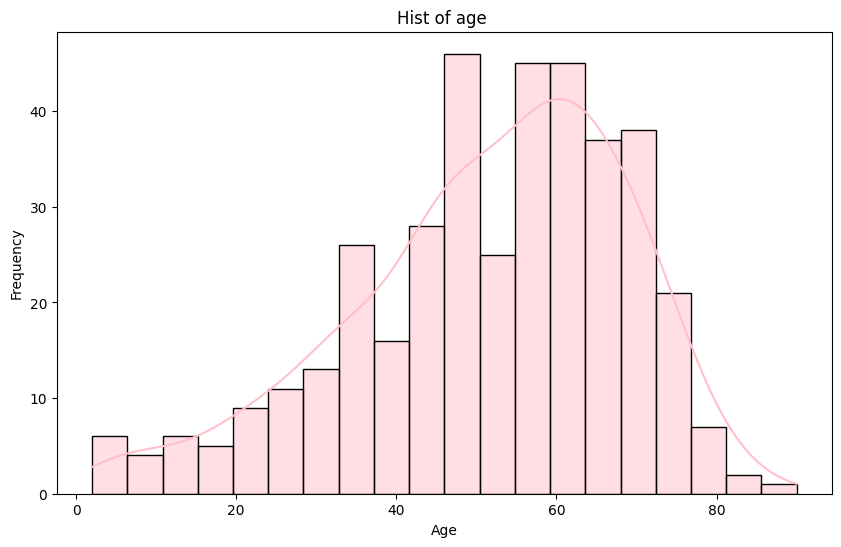

In [245]:
# univariate analysis

plt.figure(figsize = (10,6))
sns.histplot(df["Age"].dropna(), kde = True , bins = 20 , color = "pink")
plt.title("Hist of age ")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [246]:
# insights >> age is left skewed data 

In [247]:
df.columns 

Index(['Age', 'Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar',
       'Red_Blood_Cells', 'Pus_Cell', 'Pus_Cell_Clumps', 'Bacteria',
       'Blood_Glucose_Random', 'Blood_Urea', 'Serum_Creatinine', 'Sodium',
       'Potassium', 'Hemoglobin', 'Packed_Cell_Volume',
       'White_Blood_Cell_Count', 'Red_Blood_Cell_Count', 'Hypertension',
       'Diabetes_Mellitus', 'Coronary_Artery_Disease', 'Appetite',
       'Pedal_Edema', 'Anemia', 'Class'],
      dtype='object')

<Axes: xlabel='Hypertension', ylabel='count'>

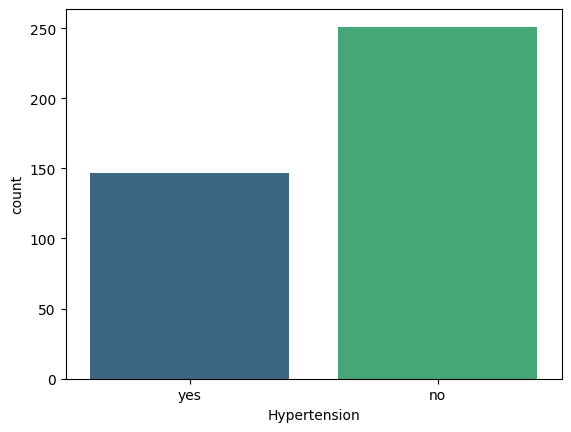

In [248]:
sns.countplot(x = "Hypertension" , data = df , palette = "viridis")

In [249]:
# 150 of themm have hypertension 

<Axes: xlabel='Class', ylabel='Blood_Urea'>

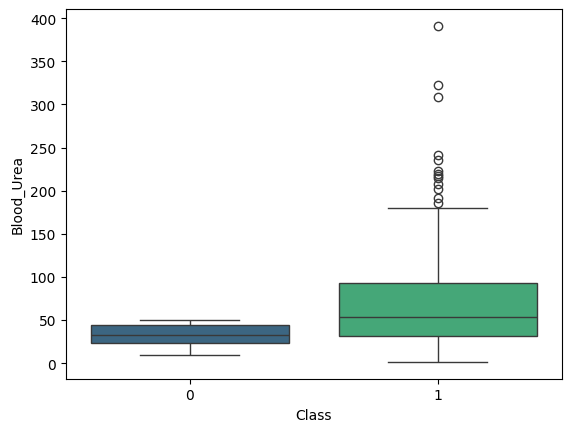

In [250]:
sns.boxplot(x = "Class" , y = "Blood_Urea" , data = df, palette = "viridis")

In [251]:
# insights >> people with kidney disease has higher blood _ures wiith outliers , median value is alos highest 

<Axes: xlabel='Class', ylabel='Serum_Creatinine'>

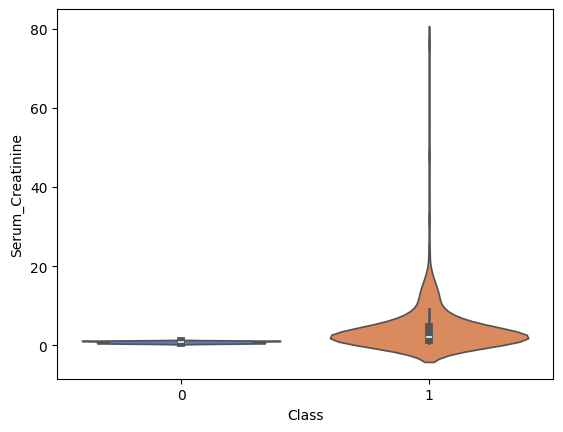

In [252]:
sns.violinplot(x = "Class", y =  "Serum_Creatinine", data = df , palette =  "muted")

<Axes: xlabel='Anemia', ylabel='count'>

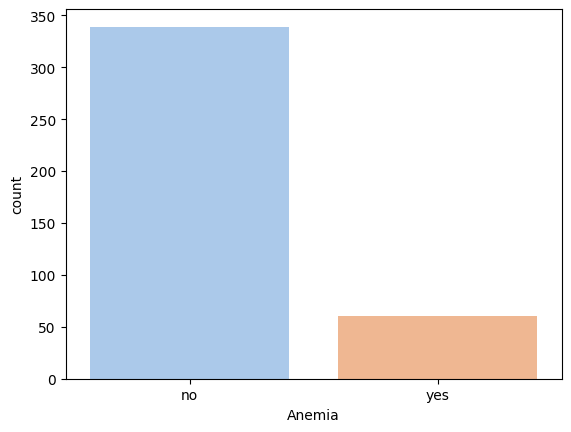

In [253]:
sns.countplot(x= "Anemia", data = df ,palette = "pastel" )

In [254]:
# majority of people is not suffering from anemia 

<Axes: ylabel='count'>

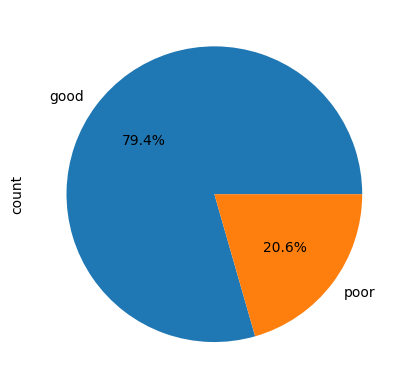

In [255]:
df.Appetite.value_counts().plot.pie(autopct = "%1.1f%%")

<Axes: ylabel='count'>

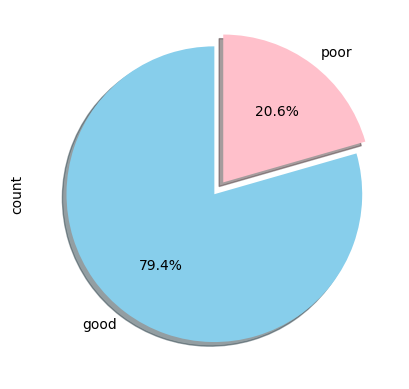

In [256]:
df.Appetite.value_counts().plot.pie(autopct = "%1.1f%%", colors = ["skyblue", "pink"], explode = (0,0.1), startangle = 90,shadow = True)

In [257]:
df.columns

Index(['Age', 'Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar',
       'Red_Blood_Cells', 'Pus_Cell', 'Pus_Cell_Clumps', 'Bacteria',
       'Blood_Glucose_Random', 'Blood_Urea', 'Serum_Creatinine', 'Sodium',
       'Potassium', 'Hemoglobin', 'Packed_Cell_Volume',
       'White_Blood_Cell_Count', 'Red_Blood_Cell_Count', 'Hypertension',
       'Diabetes_Mellitus', 'Coronary_Artery_Disease', 'Appetite',
       'Pedal_Edema', 'Anemia', 'Class'],
      dtype='object')

In [258]:
df.Pus_Cell_Clumps

0      notpresent
1      notpresent
2      notpresent
3         present
4      notpresent
          ...    
395    notpresent
396    notpresent
397    notpresent
398    notpresent
399    notpresent
Name: Pus_Cell_Clumps, Length: 400, dtype: object

<Axes: xlabel='Pus_Cell_Clumps', ylabel='count'>

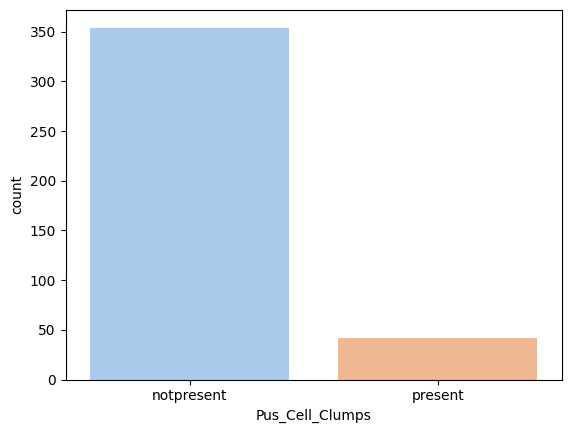

In [259]:
sns.countplot(x = "Pus_Cell_Clumps", data = df , palette = "pastel")

<Axes: xlabel='White_Blood_Cell_Count', ylabel='Count'>

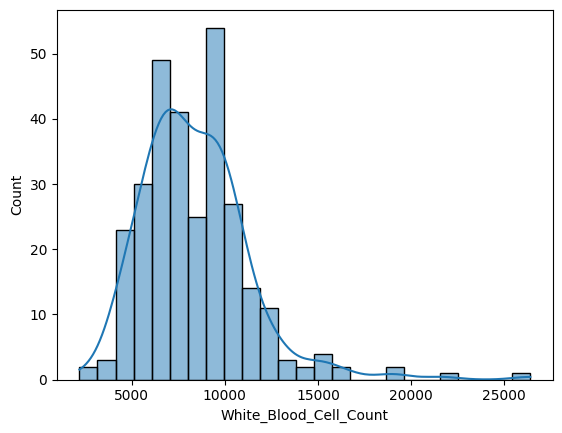

In [260]:
sns.histplot(df["White_Blood_Cell_Count"].dropna(), kde = True)

In [261]:
# donut plot >>donut chart or ring chart . it is essentially a pie chart with a hole in the centre
# byb specifying wedge props value 
# used to display proportion  .


<Axes: ylabel='count'>

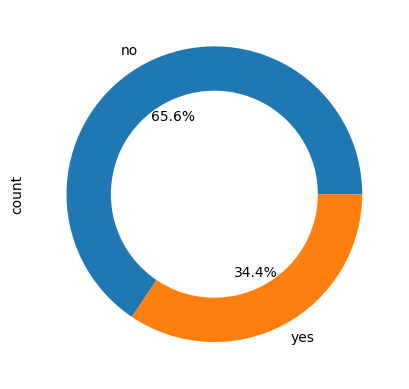

In [262]:
df["Diabetes_Mellitus"].value_counts().plot.pie(autopct = "%1.1f%%", wedgeprops = dict(width = 0.3))

<Axes: xlabel='Coronary_Artery_Disease', ylabel='count'>

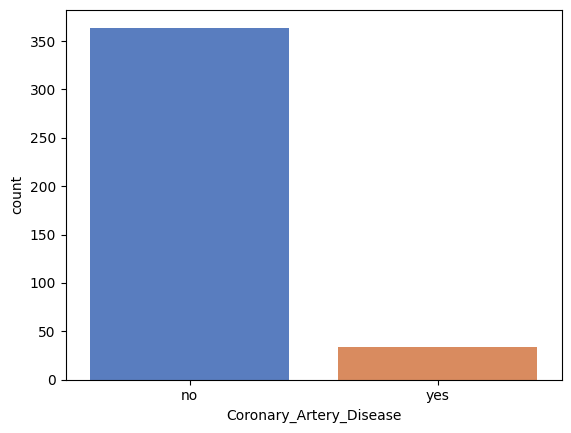

In [263]:
sns.countplot(x = "Coronary_Artery_Disease" , data = df, palette = "muted")

# bivariate analysis

<Axes: xlabel='Age', ylabel='Blood_Pressure'>

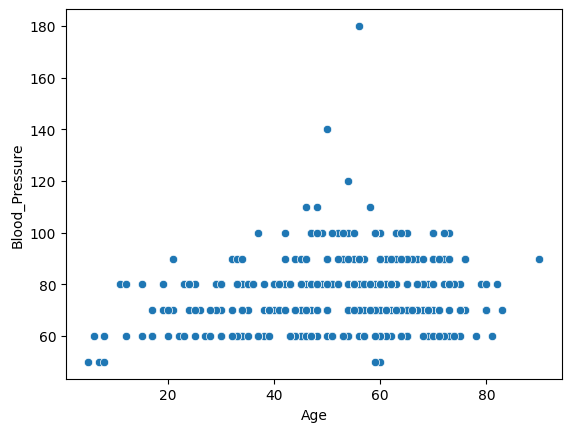

In [264]:
sns.scatterplot(x = "Age", y = "Blood_Pressure", data = df , palette = "muted")

<Axes: xlabel='Age', ylabel='Blood_Pressure'>

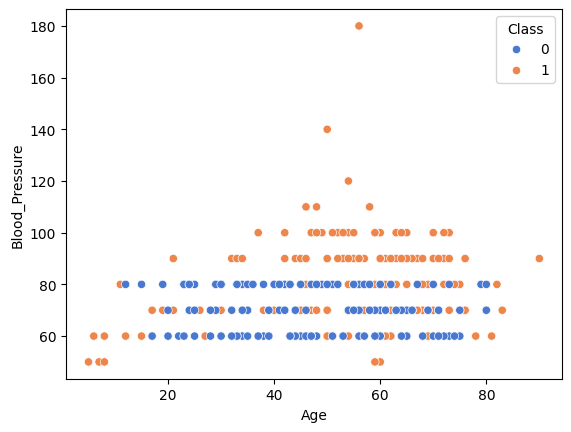

In [265]:
sns.scatterplot(x = "Age", y = "Blood_Pressure", data = df ,hue = "Class", palette = "muted")

<Axes: xlabel='Diabetes_Mellitus', ylabel='Albumin'>

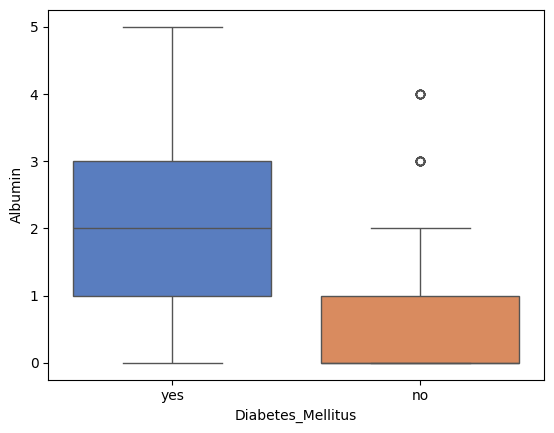

In [266]:
sns.boxplot(x = "Diabetes_Mellitus", y = "Albumin" , data = df , palette = "muted")

<Axes: xlabel='Diabetes_Mellitus', ylabel='Albumin'>

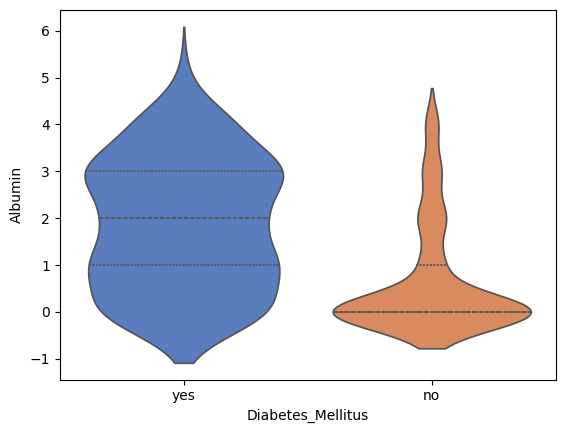

In [267]:
sns.violinplot(x = "Diabetes_Mellitus", y = "Albumin" , data = df , palette = "muted", inner = "quartile")

In [268]:
# Stacked bar chart >> diabetes_mellitus nd hyper tension

pd.crosstab(df["Diabetes_Mellitus"], df["Hypertension"])
#  crosstab  >> summarises the data 

Hypertension,no,yes
Diabetes_Mellitus,,
no,220,41
yes,31,106


<Axes: xlabel='Diabetes_Mellitus'>

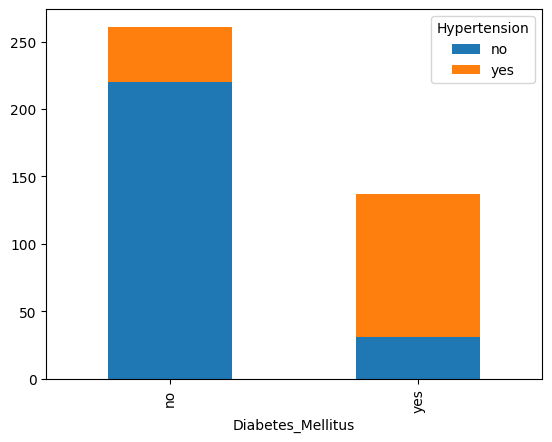

In [269]:
Diabetes_Hypertension =pd.crosstab(df["Diabetes_Mellitus"], df["Hypertension"])
Diabetes_Hypertension.plot(kind = "bar", stacked = "True")


# Multivariate analysis

In [270]:
df.columns

Index(['Age', 'Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar',
       'Red_Blood_Cells', 'Pus_Cell', 'Pus_Cell_Clumps', 'Bacteria',
       'Blood_Glucose_Random', 'Blood_Urea', 'Serum_Creatinine', 'Sodium',
       'Potassium', 'Hemoglobin', 'Packed_Cell_Volume',
       'White_Blood_Cell_Count', 'Red_Blood_Cell_Count', 'Hypertension',
       'Diabetes_Mellitus', 'Coronary_Artery_Disease', 'Appetite',
       'Pedal_Edema', 'Anemia', 'Class'],
      dtype='object')

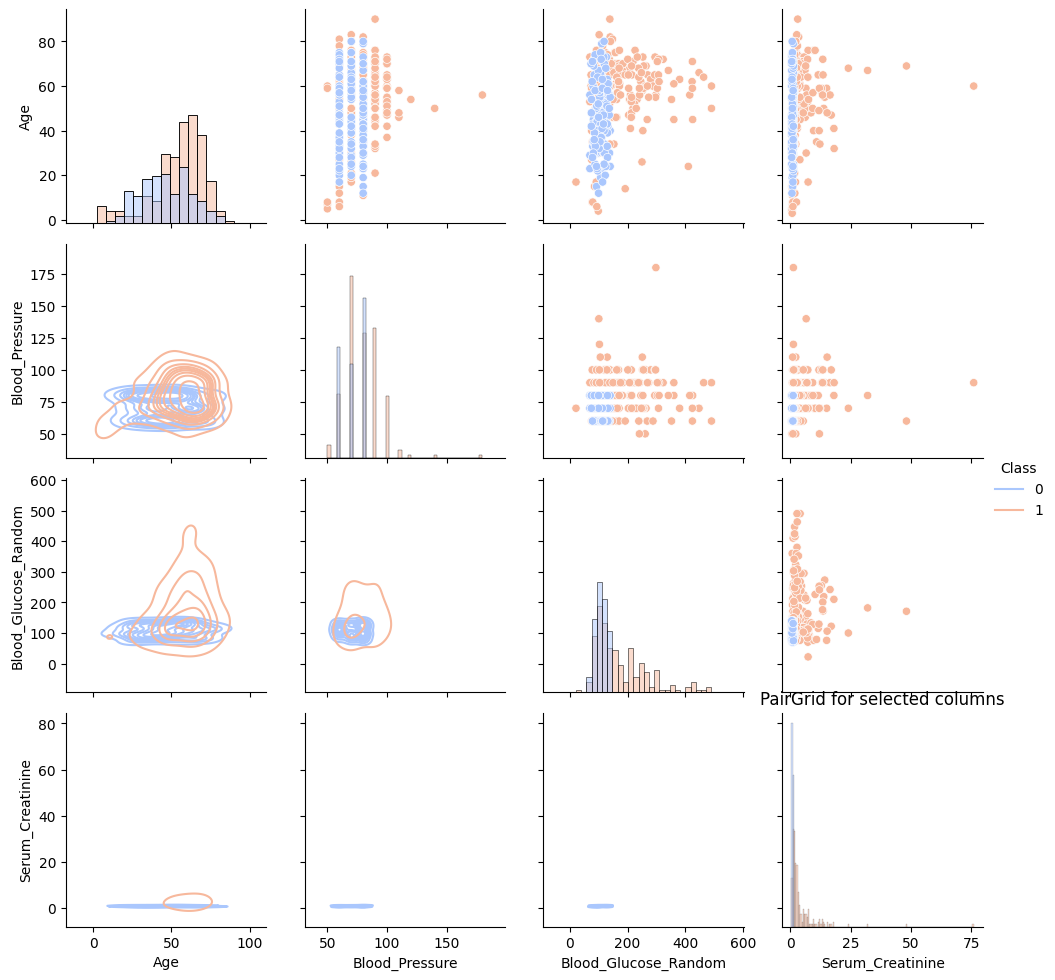

In [271]:
cols = ["Age", "Blood_Pressure", "Blood_Glucose_Random","Serum_Creatinine", "Class"]
g = sns.PairGrid(df[cols], hue='Class', palette = 'coolwarm')
g.map_upper(sns.scatterplot) # upper corner plot
g.map_lower(sns.kdeplot, cmap = 'Blues_d') # diagonal plot 
g.map_diag(sns.histplot) # lower corner plot
g.add_legend()
plt.title("PairGrid for selected columns")
plt.show()

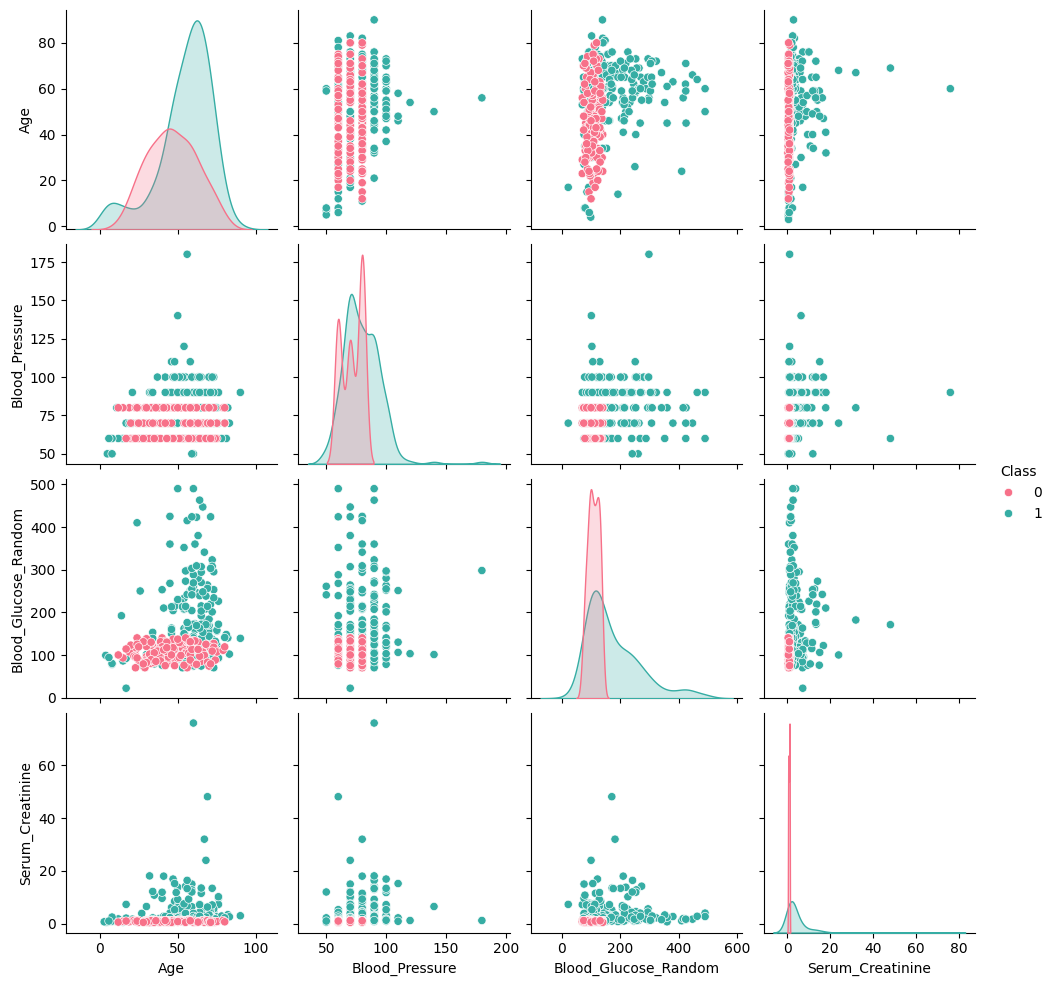

In [272]:
cols = ["Age", "Blood_Pressure", "Blood_Glucose_Random","Serum_Creatinine", "Class"]
sns.pairplot(df[cols], hue = 'Class', palette = 'husl')

In [273]:
df.corr(numeric_only = True)

,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Blood_Glucose_Random,Blood_Urea,Serum_Creatinine,Sodium,Potassium,Hemoglobin,Packed_Cell_Volume,White_Blood_Cell_Count,Red_Blood_Cell_Count,Class
Age,1.000000,0.159480,-0.191096,0.122091,0.220866,0.244992,0.196985,0.132531,-0.100046,0.058377,-0.192928,-0.242119,0.118339,-0.268896,0.227268
Blood_Pressure,0.159480,1.000000,-0.218836,0.160689,0.222576,0.160193,0.188517,0.146222,-0.116422,0.075151,-0.306540,-0.326319,0.029753,-0.261936,0.294077
Specific_Gravity,-0.191096,-0.218836,1.000000,-0.469760,-0.296234,-0.374710,-0.314295,-0.361473,0.412190,-0.072787,0.602582,0.603560,-0.236215,0.579476,-0.732163
Albumin,0.122091,0.160689,-0.469760,1.000000,0.269305,0.379464,0.453528,0.399198,-0.459896,0.129038,-0.634632,-0.611891,0.231989,-0.566437,0.627090
Sugar,0.220866,0.222576,-0.296234,0.269305,1.000000,0.717827,0.168583,0.223244,-0.131776,0.219450,-0.224775,-0.239189,0.184893,-0.237448,0.344070
Blood_Glucose_Random,0.244992,0.160193,-0.374710,0.379464,0.717827,1.000000,0.143322,0.114875,-0.267848,0.066966,-0.306189,-0.301385,0.150015,-0.281541,0.419672
Blood_Urea,0.196985,0.188517,-0.314295,0.453528,0.168583,0.143322,1.000000,0.586368,-0.323054,0.357049,-0.610360,-0.607621,0.050462,-0.579087,0.380605
Serum_Creatinine,0.132531,0.146222,-0.361473,0.399198,0.223244,0.114875,0.586368,1.000000,-0.690158,0.326107,-0.401670,-0.404193,-0.006390,-0.400852,0.299969
Sodium,-0.100046,-0.116422,0.412190,-0.459896,-0.131776,-0.267848,-0.323054,-0.690158,1.000000,0.097887,0.365183,0.376914,0.007277,0.344873,-0.375674
Potassium,0.058377,0.075151,-0.072787,0.129038,0.219450,0.066966,0.357049,0.326107,0.097887,1.000000,-0.133746,-0.163182,-0.105576,-0.158309,0.084541


<Axes: >

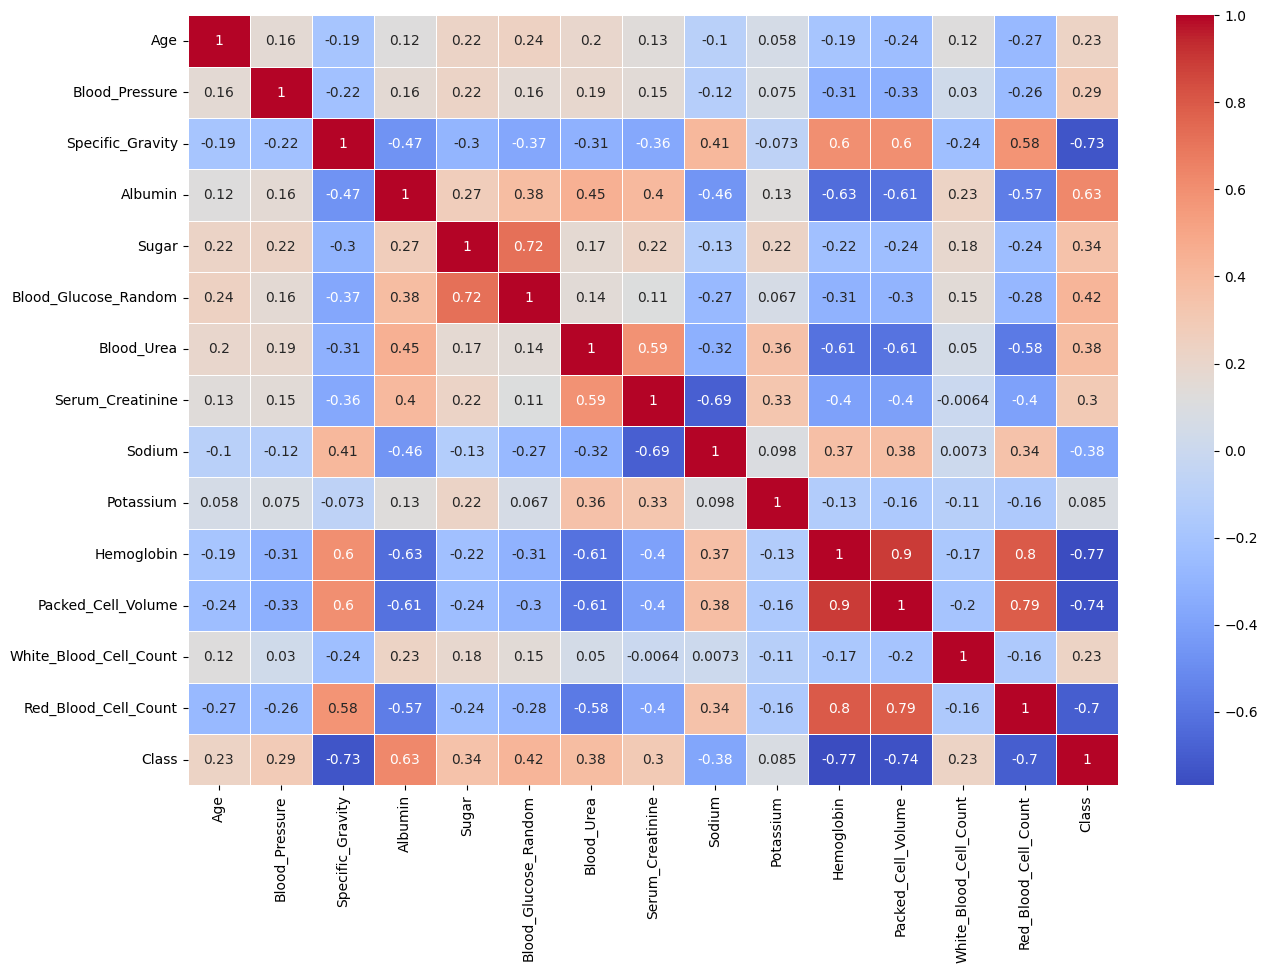

In [274]:
corr = df.corr(numeric_only=True)
plt.figure(figsize = (15, 10))
sns.heatmap(corr, annot = True, cmap = 'coolwarm', linewidth = .5)

<Axes: xlabel='Diabetes_Mellitus', ylabel='Age'>

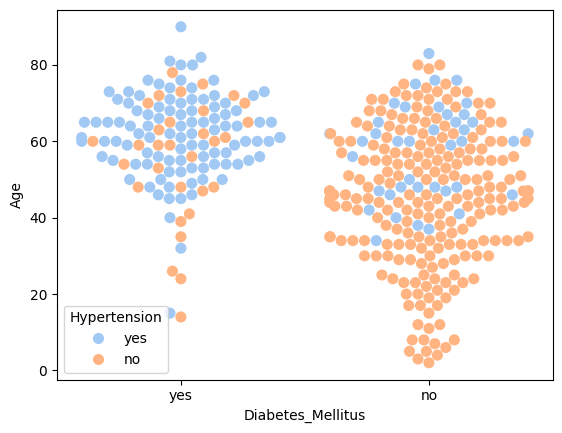

In [275]:
sns.swarmplot(x='Diabetes_Mellitus', y='Age', hue='Hypertension', data=df, palette='pastel', size=8)

In [276]:
#  swarm plot allows to see al the overlapping data as well

In [281]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [283]:
df.isnull().sum()

Age                          9
Blood_Pressure              12
Specific_Gravity            47
Albumin                     46
Sugar                       49
Red_Blood_Cells            152
Pus_Cell                    65
Pus_Cell_Clumps              4
Bacteria                     4
Blood_Glucose_Random        44
Blood_Urea                  19
Serum_Creatinine            17
Sodium                      87
Potassium                   88
Hemoglobin                  52
Packed_Cell_Volume          71
White_Blood_Cell_Count     106
Red_Blood_Cell_Count       131
Hypertension                 2
Diabetes_Mellitus            2
Coronary_Artery_Disease      2
Appetite                     1
Pedal_Edema                  1
Anemia                       1
Class                        0
dtype: int64

In [284]:
#replace with median
median_values = df[num_cols].median()

In [285]:
median_values

Age                         55.00
Blood_Pressure              80.00
Specific_Gravity             1.02
Albumin                      0.00
Sugar                        0.00
Blood_Glucose_Random       121.00
Blood_Urea                  42.00
Serum_Creatinine             1.30
Sodium                     138.00
Potassium                    4.40
Hemoglobin                  12.65
Packed_Cell_Volume          40.00
White_Blood_Cell_Count    8000.00
Red_Blood_Cell_Count         4.80
dtype: float64

In [286]:
df[num_cols] = df[num_cols].fillna(median_values)

In [287]:
df[num_cols].isna().sum()

Age                       0
Blood_Pressure            0
Specific_Gravity          0
Albumin                   0
Sugar                     0
Blood_Glucose_Random      0
Blood_Urea                0
Serum_Creatinine          0
Sodium                    0
Potassium                 0
Hemoglobin                0
Packed_Cell_Volume        0
White_Blood_Cell_Count    0
Red_Blood_Cell_Count      0
dtype: int64

In [288]:
mode_values = df.mode().iloc[0]

In [289]:
df[cat_cols] = df[cat_cols].fillna(mode_values)

In [290]:
df[cat_cols].isna().sum()

Red_Blood_Cells            0
Pus_Cell                   0
Pus_Cell_Clumps            0
Bacteria                   0
Hypertension               0
Diabetes_Mellitus          0
Coronary_Artery_Disease    0
Appetite                   0
Pedal_Edema                0
Anemia                     0
Class                      0
dtype: int64

In [291]:
df.dtypes

Age                        float64
Blood_Pressure             float64
Specific_Gravity           float64
Albumin                    float64
Sugar                      float64
Red_Blood_Cells             object
Pus_Cell                    object
Pus_Cell_Clumps             object
Bacteria                    object
Blood_Glucose_Random       float64
Blood_Urea                 float64
Serum_Creatinine           float64
Sodium                     float64
Potassium                  float64
Hemoglobin                 float64
Packed_Cell_Volume         float64
White_Blood_Cell_Count     float64
Red_Blood_Cell_Count       float64
Hypertension                object
Diabetes_Mellitus           object
Coronary_Artery_Disease     object
Appetite                    object
Pedal_Edema                 object
Anemia                      object
Class                        int64
dtype: object

In [295]:
# few columns are  object >>> convert obj to num

In [292]:
#encoding
from sklearn.preprocessing import LabelEncoder

In [293]:
LabelEncoder = LabelEncoder()
for col in cat_cols:
    df[col] = LabelEncoder.fit_transform(df[col])

In [294]:
df.head()

,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Red_Blood_Cells,Pus_Cell,Pus_Cell_Clumps,Bacteria,Blood_Glucose_Random,...,Packed_Cell_Volume,White_Blood_Cell_Count,Red_Blood_Cell_Count,Hypertension,Diabetes_Mellitus,Coronary_Artery_Disease,Appetite,Pedal_Edema,Anemia,Class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,1


In [296]:
df.dtypes

Age                        float64
Blood_Pressure             float64
Specific_Gravity           float64
Albumin                    float64
Sugar                      float64
Red_Blood_Cells              int64
Pus_Cell                     int64
Pus_Cell_Clumps              int64
Bacteria                     int64
Blood_Glucose_Random       float64
Blood_Urea                 float64
Serum_Creatinine           float64
Sodium                     float64
Potassium                  float64
Hemoglobin                 float64
Packed_Cell_Volume         float64
White_Blood_Cell_Count     float64
Red_Blood_Cell_Count       float64
Hypertension                 int64
Diabetes_Mellitus            int64
Coronary_Artery_Disease      int64
Appetite                     int64
Pedal_Edema                  int64
Anemia                       int64
Class                        int64
dtype: object

In [299]:
X = df.drop('Class', axis = 1)
y = df['Class']

In [ ]:
#train-test split and ml model training